In [1]:
import pandas as pd
import numpy as np
import altair as alt
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/nih_merged2_with_traits.csv", engine='python')

In [3]:
df.head()

,Unnamed: 0,grant_id,subgrant_id,core_award_number,full_award_number,activity_code,institute_code,subproject_id,current_status,detailed_status,...,Private,Public,R1,R2,Research,Rural,Tribal/Native Serving,project_duration,duration_bin,years_funded_bin
0,0,AA007459,NaN,T32AA007459,5T32AA007459-40,T32,AA,NaN,Restored,Unfrozen (confirmed),...,1,0,1,0,0,0,0,14578,"(12052.6, 16069.8]","(35.167, 42.0]"
1,1,AA019072,NaN,P01AA019072,5P01AA019072-15,P01,AA,NaN,Restored,Unfrozen (confirmed),...,1,0,1,0,0,0,0,5722,"(4018.2, 8035.4]","(14.667, 21.5]"
2,2,AA024434,NaN,R01AA024434,5R01AA024434-10,R01,AA,NaN,Restored,Unfrozen (confirmed),...,1,0,1,0,0,0,0,3632,"(-19.086, 4018.2]","(7.833, 14.667]"
3,3,AA026186,NaN,R01AA026186,5R01AA026186-10,R01,AA,NaN,Restored,Unfrozen (confirmed),...,1,0,1,0,0,0,0,3833,"(-19.086, 4018.2]","(7.833, 14.667]"
4,4,AA026297,NaN,R01AA026297,5R01AA026297-09,R01,AA,NaN,Restored,Unfrozen (confirmed),...,1,0,1,0,0,0,0,3926,"(-19.086, 4018.2]","(7.833, 14.667]"


In [4]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 5757
Columns: 123


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5757 entries, 0 to 5756
Columns: 123 entries, Unnamed: 0 to years_funded_bin
dtypes: bool(5), float64(18), int64(12), object(88)
memory usage: 5.2+ MB


In [6]:
df.isna().sum().sort_values(ascending=False).head(20)

,0
cong_dist,5757
subproject_id,5756
covid_response,5705
subgrant_id,5081
post_termination_deobligation,5077
spending_categories_desc,4032
unfrozen_date,3519
latest_reinstatement_date,3364
first_reinstatement_date,3364
frozen_date,2934


In [7]:
df["has_been_terminated"].value_counts(dropna=False)

,count
has_been_terminated,
True,3426
False,2331


In [8]:
df.columns

Index(['Unnamed: 0', 'grant_id', 'subgrant_id', 'core_award_number',
       'full_award_number', 'activity_code', 'institute_code', 'subproject_id',
       'current_status', 'detailed_status',
       ...
       'Private', 'Public', 'R1', 'R2', 'Research', 'Rural',
       'Tribal/Native Serving', 'project_duration', 'duration_bin',
       'years_funded_bin'],
      dtype='object', length=123)

In [9]:
[c for c in df.columns if "categor" in c.lower()]

['spending_categories',
 'categories_predicted',
 'funding_category',
 'spending_categories_desc']

In [10]:
df["spending_categories"].dropna().head(10)

,spending_categories
0,"Substance Misuse, Alcoholism, Alcohol Use and ..."
1,"HIV/AIDS, Clinical Research, Prevention, Women..."
2,"Genetics, Behavioral and Social Science, Brain..."
3,"Behavioral and Social Science, Brain Disorders..."
4,"Cancer, Rare Diseases, Digestive Diseases, Gen..."
5,"Clinical Research, Prevention, Women's Health,..."
6,"Alcoholism, Alcohol Use and Health, Behavioral..."
8,"Alcoholism, Alcohol Use and Health, Basic Beha..."
9,"Alcoholism, Alcohol Use and Health, Basic Beha..."
10,"Alcoholism, Alcohol Use and Health, Basic Beha..."


In [11]:
df["spending_categories"].notna().sum()

np.int64(5158)

In [12]:
categories = df["spending_categories"].dropna()

print("Infectious Diseases:",
      categories.str.contains("Infectious Diseases", case=False).sum())

print("Mental Health:",
      categories.str.contains("Mental Health", case=False).sum())

print("Alzheimer",
      categories.str.contains("Alzheimer", case=False).sum())

print("Health Disparities:",
      categories.str.contains("Health Disparities", case=False).sum())

print("Cancer:",
      categories.str.contains("Cancer", case=False).sum())

Infectious Diseases: 1010
Mental Health: 985
Alzheimer 394
Health Disparities: 1306
Cancer: 674


In [13]:
infectious = df[
    df["spending_categories"]
      .fillna("")
      .str.contains("Infectious Diseases", case=False)
]

infectious["has_been_terminated"].value_counts(normalize=True)

,proportion
has_been_terminated,
True,0.650495
False,0.349505


In [14]:
topics = [
    "Cancer",
    "Infectious Diseases",
    "Mental Health",
    "Health Disparities"
]

results = []

for topic in topics:
    subset = df[
        df["spending_categories"]
          .fillna("")
          .str.contains(topic, case=False)
    ]

    termination_rate = subset["has_been_terminated"].mean()

    results.append({
        "Topic": topic,
        "Termination Rate": termination_rate,
        "Total Grants": len(subset)
    })

results_df = pd.DataFrame(results)
results_df

,Topic,Termination Rate,Total Grants
0,Cancer,0.502967,674
1,Infectious Diseases,0.650495,1010
2,Mental Health,0.649746,985
3,Health Disparities,0.718989,1306


In [15]:
alt.Chart(results_df).mark_bar().encode(
    x=alt.X("Topic:N", sort="-y"),
    y=alt.Y("Termination Rate:Q"),
    tooltip=["Topic", "Termination Rate", "Total Grants"]
).properties(
    title="Termination Rates by Research Area"
)

alt.Chart(...)

In [16]:
from collections import Counter

all_categories = []

for cats in df["spending_categories"].dropna():
    all_categories.extend([c.strip() for c in cats.split(",")])

Counter(all_categories).most_common(20)

[('Clinical Research', 2109),
 ('Behavioral and Social Science', 1933),
 ('Prevention', 1586),
 ('Neurosciences', 1525),
 ('Genetics', 1482),
 ('Social Determinants of Health', 1335),
 ('Health Disparities and Racial or Ethnic Minority Health Research', 1295),
 ('Health Disparities Research', 1225),
 ('Brain Disorders', 1207),
 ('Pediatric', 1088),
 ('Infectious Diseases', 1003),
 ('Mental Health', 985),
 ('Biotechnology', 977),
 ('Basic Behavioral and Social Science', 970),
 ('Aging', 867),
 ('Clinical Trials and Supportive Activities', 857),
 ('Bioengineering', 841),
 ('Rare Diseases', 823),
 ('Human Genome', 688),
 ('Cancer', 663)]

In [17]:
topics = [
    "Clinical Research",
    "Behavioral and Social Science",
    "Prevention",
    "Neurosciences",
    "Genetics",
    "Social Determinants of Health",
    "Health Disparities Research",
    "Health Disparities and Racial or Ethnic Minority Health Research",
    "Infectious Diseases",
    "Mental Health",
    "Cancer"
]

results = []

for topic in topics:
    subset = df[
        df["spending_categories"]
        .fillna("")
        .str.contains(topic, case=False)
    ]

    results.append({
        "Topic": topic,
        "Termination Rate (%)": subset["has_been_terminated"].mean() * 100,
        "Total Grants": len(subset)
    })

results_df = pd.DataFrame(results).sort_values(
    "Termination Rate (%)",
    ascending=False
)

results_df

,Topic,Termination Rate (%),Total Grants
5,Social Determinants of Health,72.808989,1335
6,Health Disparities Research,72.734694,1225
7,Health Disparities and Racial or Ethnic Minori...,72.046332,1295
1,Behavioral and Social Science,66.212121,1980
8,Infectious Diseases,65.049505,1010
9,Mental Health,64.974619,985
2,Prevention,59.298685,1597
0,Clinical Research,57.989569,2109
3,Neurosciences,52.000000,1525
4,Genetics,50.472335,1482


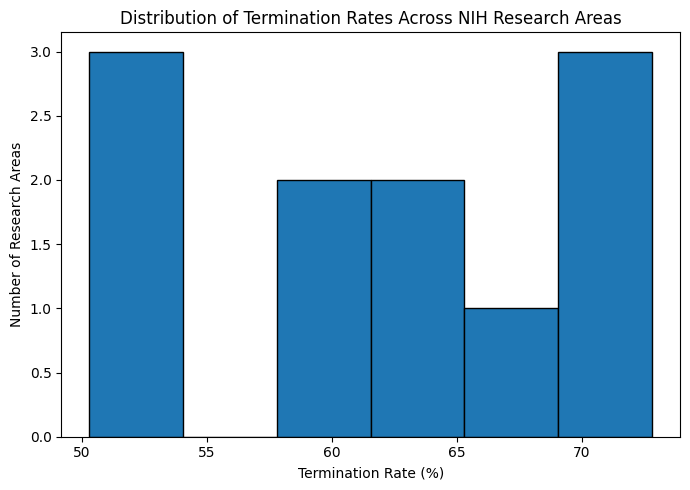

In [18]:
plt.figure(figsize=(7, 5))

plt.hist(
    results_df["Termination Rate (%)"],
    bins=6,
    edgecolor="black"
)

plt.title("Distribution of Termination Rates Across NIH Research Areas")
plt.xlabel("Termination Rate (%)")
plt.ylabel("Number of Research Areas")

plt.tight_layout()
plt.show()

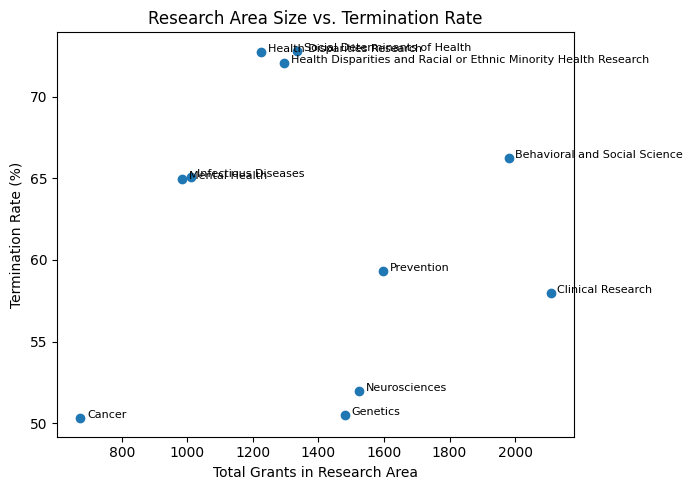

In [19]:
plt.figure(figsize=(7, 5))

plt.scatter(
    results_df["Total Grants"],
    results_df["Termination Rate (%)"]
)

for i, row in results_df.iterrows():
    plt.text(
        row["Total Grants"] + 20,
        row["Termination Rate (%)"],
        row["Topic"],
        fontsize=8
    )

plt.title("Research Area Size vs. Termination Rate")
plt.xlabel("Total Grants in Research Area")
plt.ylabel("Termination Rate (%)")

plt.tight_layout()
plt.show()

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []

for _, row in df.dropna(subset=["spending_categories"]).iterrows():
    categories = [c.strip() for c in row["spending_categories"].split(",")]

    for category in categories:
        rows.append({
            "Topic": category,
            "has_been_terminated": row["has_been_terminated"]
        })

category_df = pd.DataFrame(rows)

all_results_df = (
    category_df
    .groupby("Topic")
    .agg(
        Total_Grants=("has_been_terminated", "count"),
        Termination_Rate=("has_been_terminated", "mean")
    )
    .reset_index()
)

all_results_df["Termination Rate (%)"] = all_results_df["Termination_Rate"] * 100

# Keep categories with enough grants to compare meaningfully
all_results_df = all_results_df[all_results_df["Total_Grants"] >= 100]

all_results_df = all_results_df.sort_values("Termination Rate (%)", ascending=False)

all_results_df.head(20)

,Topic,Total_Grants,Termination_Rate,Termination Rate (%)
251,Rural Health,152,0.835526,83.552632
76,Coronaviruses Disparities and At-Risk Populations,101,0.831683,83.168317
306,Vaccine Related,159,0.786164,78.616352
148,Immunization,191,0.785340,78.534031
74,Coronaviruses,175,0.765714,76.571429
243,Racial and Ethnic Minority Health Research,627,0.762360,76.236045
313,Violence Research,105,0.742857,74.285714
39,Building Research Capacity at Institutions wit...,567,0.737213,73.721340
263,Social Determinants of Health,1335,0.728090,72.808989
128,Health Disparities Research,1225,0.727347,72.734694


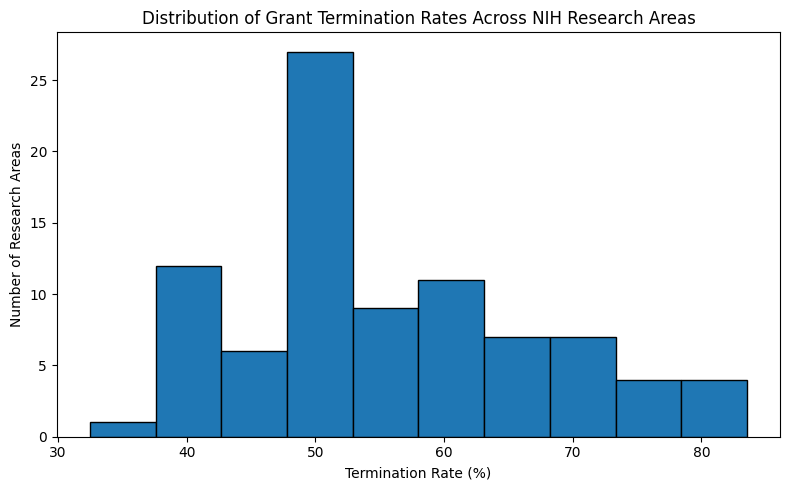

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(all_results_df["Termination Rate (%)"],
         bins=10,
         edgecolor="black")

plt.title("Distribution of Grant Termination Rates Across NIH Research Areas")
plt.xlabel("Termination Rate (%)")
plt.ylabel("Number of Research Areas")

plt.tight_layout()
plt.savefig("termination_histogram.png", dpi=300, bbox_inches="tight")
plt.show()

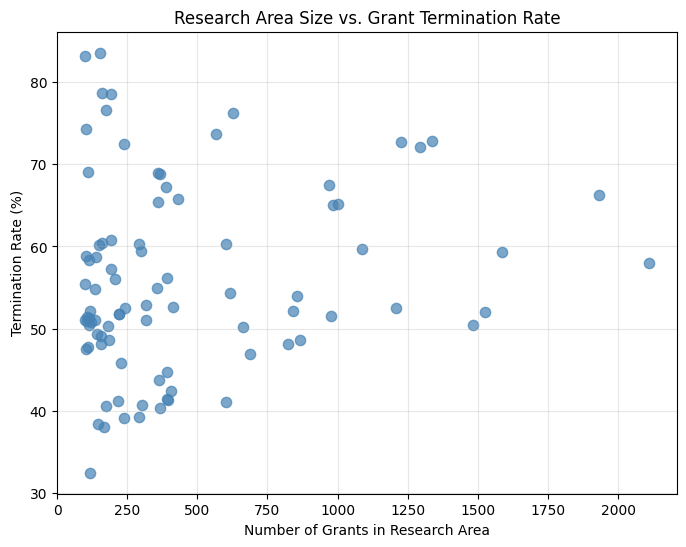

In [22]:
plt.figure(figsize=(8,6))

plt.scatter(
    all_results_df["Total_Grants"],
    all_results_df["Termination_Rate"] * 100,
    color="steelblue",
    s=55,
    alpha=0.7
)

plt.title("Research Area Size vs. Grant Termination Rate")
plt.xlabel("Number of Grants in Research Area")
plt.ylabel("Termination Rate (%)")

plt.grid(alpha=0.3)

plt.savefig("termination_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

In [23]:
plot_df = all_results_df.head(20).copy()
plot_df = plot_df.sort_values("Termination Rate (%)", ascending=False)

bar_chart = alt.Chart(plot_df).mark_bar().encode(
    x=alt.X("Termination Rate (%):Q", title="Termination Rate (%)"),
    y=alt.Y("Topic:N", sort="-x", title="Research Area"),
    tooltip=[
        alt.Tooltip("Topic:N", title="Research Area"),
        alt.Tooltip("Termination Rate (%):Q", title="Termination Rate (%)", format=".1f"),
        alt.Tooltip("Total_Grants:Q", title="Total Grants")
    ]
).properties(
    width=700,
    height=500,
    title="Grant Termination Rates by NIH Research Area"
)

bar_chart

alt.Chart(...)

In [24]:
bar_chart.save("termination_bar_interactive.html")

In [25]:

alt.data_transformers.disable_max_rows()

# Start with the research-area table you already created
viz_df = all_results_df.copy()

# Keywords used to identify broadly public health-related research areas
public_health_keywords = [
    "rural",
    "health disparities",
    "minority health",
    "racial or ethnic",
    "social determinants",
    "infectious disease",
    "covid",
    "coronavirus",
    "vaccine",
    "immunization",
    "prevention",
    "population health",
    "maternal health",
    "child health",
    "women's health",
    "violence",
    "mental health"
]

def classify_topic(topic):
    topic_lower = topic.lower()

    if any(keyword in topic_lower for keyword in public_health_keywords):
        return "Public health-related"
    return "Other NIH research area"

viz_df["Research Group"] = viz_df["Topic"].apply(classify_topic)

# See which categories were classified as public health-related
viz_df[viz_df["Research Group"] == "Public health-related"][
    ["Topic", "Total_Grants", "Termination Rate (%)"]
].sort_values("Termination Rate (%)", ascending=False)

,Topic,Total_Grants,Termination Rate (%)
251,Rural Health,152,83.552632
76,Coronaviruses Disparities and At-Risk Populations,101,83.168317
306,Vaccine Related,159,78.616352
148,Immunization,191,78.534031
74,Coronaviruses,175,76.571429
243,Racial and Ethnic Minority Health Research,627,76.236045
313,Violence Research,105,74.285714
263,Social Determinants of Health,1335,72.808989
128,Health Disparities Research,1225,72.734694
129,Health Disparities and Racial or Ethnic Minori...,1295,72.046332


In [26]:
import altair as alt

# Dropdown to filter by research group
group_dropdown = alt.binding_select(
    options=[
        "All",
        "Public health-related",
        "Other NIH research area"
    ],
    name="Research group: "
)

group_choice = alt.param(
    name="Research_Group_Filter",
    value="All",
    bind=group_dropdown
)

# Search box for topic names
search_box = alt.binding(
    input="search",
    name="Search research area: "
)

search_term = alt.param(
    name="Topic_Search",
    value="",
    bind=search_box
)

# Slider to remove categories with small sample sizes
minimum_grants_slider = alt.binding_range(
    min=0,
    max=500,
    step=25,
    name="Minimum number of grants: "
)

minimum_grants = alt.param(
    name="Minimum_Grants",
    value=100,
    bind=minimum_grants_slider
)

# Highlight a bar when the user hovers over it
hover = alt.selection_point(
    fields=["Topic"],
    on="pointerover",
    empty=False
)

# NIH-inspired colors
NIH_NAVY = "#183B56"
NIH_BLUE = "#009CC6"
NIH_TEXT = "#243746"
NIH_GRID = "#D9E2E8"

# Shared color scale
research_colors = alt.Scale(
    domain=[
        "Public health-related",
        "Other NIH research area"
    ],
    range=[
        NIH_BLUE,
        NIH_NAVY
    ]
)

# Prepare the filtered and ranked data
base = (
    alt.Chart(viz_df)
    .add_params(
        group_choice,
        search_term,
        minimum_grants,
        hover
    )
    .transform_filter(
        "(Research_Group_Filter == 'All') || "
        "(datum['Research Group'] == Research_Group_Filter)"
    )
    .transform_filter(
        "(Topic_Search == '') || "
        "(indexof(lower(datum.Topic), lower(Topic_Search)) >= 0)"
    )
    .transform_filter(
        "datum.Total_Grants >= Minimum_Grants"
    )
    .transform_window(
        rank="rank()",
        sort=[
            alt.SortField(
                "Termination Rate (%)",
                order="descending"
            )
        ]
    )
    .transform_filter(
        "datum.rank <= 20"
    )
)

# Bars
bars = base.mark_bar(
    cornerRadiusEnd=5
).encode(
    x=alt.X(
        "Termination Rate (%):Q",
        title="Termination Rate (%)",
        scale=alt.Scale(domain=[0, 100])
    ),
    y=alt.Y(
        "Topic:N",
        title=None,
        sort=alt.EncodingSortField(
            field="Termination Rate (%)",
            order="descending"
        ),
        axis=alt.Axis(
            labelLimit=360,
            labelPadding=8
        )
    ),
    color=alt.Color(
        "Research Group:N",
        title="Research group",
        scale=research_colors
    ),
    opacity=alt.condition(
        hover,
        alt.value(1),
        alt.value(0.75)
    ),
    stroke=alt.condition(
        hover,
        alt.value(NIH_NAVY),
        alt.value(None)
    ),
    strokeWidth=alt.condition(
        hover,
        alt.value(2),
        alt.value(0)
    ),
    tooltip=[
        alt.Tooltip(
            "Topic:N",
            title="Research area"
        ),
        alt.Tooltip(
            "Research Group:N",
            title="Research group"
        ),
        alt.Tooltip(
            "Termination Rate (%):Q",
            title="Termination rate",
            format=".1f"
        ),
        alt.Tooltip(
            "Total_Grants:Q",
            title="Total grants",
            format=","
        )
    ]
)

# Percentage labels at the ends of the bars
labels = base.mark_text(
    align="left",
    baseline="middle",
    dx=5,
    fontSize=11
).encode(
    x=alt.X(
        "Termination Rate (%):Q"
    ),
    y=alt.Y(
        "Topic:N",
        sort=alt.EncodingSortField(
            field="Termination Rate (%)",
            order="descending"
        )
    ),
    text=alt.Text(
        "Termination Rate (%):Q",
        format=".1f"
    ),
    color=alt.value(NIH_TEXT)
)

ranked_bar = (
    bars + labels
).properties(
    width=700,
    height=560,
    title=alt.Title(
        "Which NIH Research Areas Had the Highest Grant Termination Rates?",
        subtitle=(
            "Filter, search, or hover to explore individual research areas. "
            "Public health-related areas are shown in lighter blue."
        ),
        anchor="start",
        fontSize=20,
        subtitleFontSize=12,
        subtitlePadding=8
    )
).configure_view(
    stroke=None
).configure_axis(
    gridColor=NIH_GRID,
    labelColor=NIH_TEXT,
    titleColor=NIH_NAVY,
    labelFontSize=11,
    titleFontSize=13
).configure_title(
    color=NIH_NAVY
).configure_legend(
    orient="top",
    direction="horizontal",
    labelColor=NIH_TEXT,
    titleColor=NIH_NAVY
)

ranked_bar

alt.LayerChart(...)

In [31]:
import altair as alt
import pandas as pd
import numpy as np

# Keep research areas with at least 100 grants
comparison_df = viz_df[
    viz_df["Total_Grants"] >= 100
].copy()

# Add reproducible vertical jitter so overlapping dots remain visible
rng = np.random.default_rng(42)
comparison_df["Jitter"] = rng.uniform(
    low=-0.35,
    high=0.35,
    size=len(comparison_df)
)

# Calculate the median termination rate for each group
median_df = (
    comparison_df
    .groupby("Research Group", as_index=False)
    .agg(
        Median_Rate=("Termination Rate (%)", "median"),
        Number_of_Areas=("Topic", "count")
    )
)

# NIH-inspired colors
NIH_NAVY = "#183B56"
NIH_BLUE = "#009CC6"
NIH_TEXT = "#243746"
NIH_GRID = "#D9E2E8"

# Consistent group colors
group_colors = {
    "Public health-related": NIH_BLUE,
    "Other NIH research area": NIH_NAVY
}

def make_group_chart(group_name, color):
    group_data = comparison_df[
        comparison_df["Research Group"] == group_name
    ]

    group_median = median_df[
        median_df["Research Group"] == group_name
    ]

    # Each dot represents one NIH research area
    dots = (
        alt.Chart(group_data)
        .mark_circle(
            color=color,
            opacity=0.72,
            stroke="white",
            strokeWidth=1
        )
        .encode(
            x=alt.X(
                "Termination Rate (%):Q",
                title="Termination Rate (%)",
                scale=alt.Scale(domain=[0, 100])
            ),
            y=alt.Y(
                "Jitter:Q",
                title=None,
                axis=None,
                scale=alt.Scale(domain=[-0.5, 0.5])
            ),
            size=alt.Size(
                "Total_Grants:Q",
                title="Total grants",
                scale=alt.Scale(range=[60, 650])
            ),
            tooltip=[
                alt.Tooltip(
                    "Topic:N",
                    title="Research area"
                ),
                alt.Tooltip(
                    "Termination Rate (%):Q",
                    title="Termination rate",
                    format=".1f"
                ),
                alt.Tooltip(
                    "Total_Grants:Q",
                    title="Total grants",
                    format=","
                ),
                alt.Tooltip(
                    "Research Group:N",
                    title="Research group"
                )
            ]
        )
    )

    # Median reference line
    median_line = (
        alt.Chart(group_median)
        .mark_rule(
            color=color,
            strokeWidth=3,
            strokeDash=[7, 5]
        )
        .encode(
            x=alt.X("Median_Rate:Q")
        )
    )

    # Median label
    median_label = (
        alt.Chart(group_median)
        .mark_text(
            color=color,
            align="left",
            dx=7,
            dy=-62,
            fontSize=12,
            fontWeight="bold"
        )
        .encode(
            x=alt.X("Median_Rate:Q"),
            y=alt.value(75),
            text=alt.Text(
                "Median_Rate:Q",
                format=".1f"
            )
        )
    )

    return (
        dots + median_line + median_label
    ).properties(
        width=750,
        height=150,
        title=alt.Title(
            group_name,
            anchor="start",
            color=color,
            fontSize=16
        )
    )


public_health_chart = make_group_chart(
    "Public health-related",
    group_colors["Public health-related"]
)

other_chart = make_group_chart(
    "Other NIH research area",
    group_colors["Other NIH research area"]
)

comparison_chart = (
    alt.vconcat(
        public_health_chart,
        other_chart,
        spacing=15
    )
    .properties(
        title=alt.Title(
            "How Do Termination Rates Compare Across Research Groups?",
            subtitle=[
                "Each circle represents one NIH research area; larger circles contain more grants.",
                "Dashed lines show the median termination rate for each group. Hover for details."
            ],
            anchor="start",
            color=NIH_NAVY,
            fontSize=20,
            subtitleColor=NIH_TEXT,
            subtitleFontSize=12,
            subtitlePadding=8
        )
    )
    .resolve_scale(
        size="shared"
    )
    .configure_view(
        stroke=None
    )
    .configure_axis(
        gridColor=NIH_GRID,
        labelColor=NIH_TEXT,
        titleColor=NIH_NAVY,
        labelFontSize=11,
        titleFontSize=13
    )
    .configure_legend(
        orient="right",
        labelColor=NIH_TEXT,
        titleColor=NIH_NAVY
    )
)

comparison_chart

alt.VConcatChart(...)

In [32]:
import altair as alt

# Dropdown for research group
scatter_group_dropdown = alt.binding_select(
    options=[
        "All",
        "Public health-related",
        "Other NIH research area"
    ],
    name="Research group: "
)

scatter_group_filter = alt.param(
    name="scatter_group_filter",
    value="All",
    bind=scatter_group_dropdown
)

# Minimum-grant slider
scatter_min_grants = alt.param(
    name="scatter_min_grants",
    value=100,
    bind=alt.binding_range(
        min=0,
        max=500,
        step=25,
        name="Minimum number of grants: "
    )
)

# NIH-inspired colors
NIH_NAVY = "#183B56"
NIH_BLUE = "#009CC6"
NIH_TEXT = "#243746"
NIH_GRID = "#D9E2E8"
NIH_GRAY = "#5B6770"

# Consistent color scale
scatter_colors = alt.Scale(
    domain=[
        "Public health-related",
        "Other NIH research area"
    ],
    range=[
        NIH_BLUE,
        NIH_NAVY
    ]
)

# Filtered base data
scatter_base = (
    alt.Chart(viz_df)
    .transform_filter(
        "datum.Total_Grants >= scatter_min_grants"
    )
    .transform_filter(
        "(scatter_group_filter == 'All') || "
        "(datum['Research Group'] == scatter_group_filter)"
    )
)

# Research-area points
scatter_points = scatter_base.mark_circle(
    opacity=0.76,
    stroke="white",
    strokeWidth=1
).encode(
    x=alt.X(
        "Total_Grants:Q",
        title="Number of Grants in Research Area",
        scale=alt.Scale(zero=False)
    ),
    y=alt.Y(
        "Termination Rate (%):Q",
        title="Termination Rate (%)",
        scale=alt.Scale(domain=[0, 100])
    ),
    size=alt.Size(
        "Total_Grants:Q",
        title="Total grants",
        scale=alt.Scale(range=[65, 650])
    ),
    color=alt.Color(
        "Research Group:N",
        title="Research group",
        scale=scatter_colors
    ),
    tooltip=[
        alt.Tooltip(
            "Topic:N",
            title="Research area"
        ),
        alt.Tooltip(
            "Research Group:N",
            title="Research group"
        ),
        alt.Tooltip(
            "Total_Grants:Q",
            title="Total grants",
            format=","
        ),
        alt.Tooltip(
            "Termination Rate (%):Q",
            title="Termination rate",
            format=".1f"
        )
    ]
)

# Overall average termination-rate reference line
average_line = (
    scatter_base
    .transform_aggregate(
        Average_Rate="mean(Termination Rate (%))"
    )
    .mark_rule(
        color=NIH_GRAY,
        strokeWidth=2,
        strokeDash=[7, 5]
    )
    .encode(
        y=alt.Y("Average_Rate:Q"),
        tooltip=[
            alt.Tooltip(
                "Average_Rate:Q",
                title="Average rate",
                format=".1f"
            )
        ]
    )
)

# Label for average line
average_label = (
    scatter_base
    .transform_aggregate(
        Average_Rate="mean(Termination Rate (%))"
    )
    .mark_text(
        align="right",
        baseline="bottom",
        dx=-5,
        dy=-5,
        color=NIH_GRAY,
        fontSize=12
    )
    .encode(
        x=alt.value(745),
        y=alt.Y("Average_Rate:Q"),
        text=alt.value("Average termination rate")
    )
)

interactive_scatter = (
    (scatter_points + average_line + average_label)
    .add_params(
        scatter_group_filter,
        scatter_min_grants
    )
    .properties(
        width=750,
        height=450,
        title=alt.Title(
            "Does Research-Area Size Explain Grant Termination Rates?",
            subtitle=[
                "Each circle represents one NIH research area.",
                "Use the controls to filter categories and hover over points for details."
            ],
            anchor="start",
            color=NIH_NAVY,
            fontSize=20,
            subtitleColor=NIH_TEXT,
            subtitleFontSize=12,
            subtitlePadding=8
        )
    )
    .configure_view(
        stroke=None
    )
    .configure_axis(
        gridColor=NIH_GRID,
        labelColor=NIH_TEXT,
        titleColor=NIH_NAVY,
        labelFontSize=11,
        titleFontSize=13
    )
    .configure_legend(
        orient="top",
        direction="horizontal",
        labelColor=NIH_TEXT,
        titleColor=NIH_NAVY
    )
)

interactive_scatter

alt.LayerChart(...)

In [33]:
# Save interactive charts as HTML
ranked_bar.save("nih_research_area_termination_rankings.html")

comparison_chart.save("nih_research_group_comparison.html")

interactive_scatter.save("nih_research_area_size_vs_termination.html")

In [30]:
df.columns

Index(['Unnamed: 0', 'grant_id', 'subgrant_id', 'core_award_number',
       'full_award_number', 'activity_code', 'institute_code', 'subproject_id',
       'current_status', 'detailed_status',
       ...
       'Private', 'Public', 'R1', 'R2', 'Research', 'Rural',
       'Tribal/Native Serving', 'project_duration', 'duration_bin',
       'years_funded_bin'],
      dtype='object', length=123)